<a href="https://colab.research.google.com/github/Addy48/23FE10CSE00457_MLWine/blob/main/LAB10%20ANN_%26_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
!pip install tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout

In [17]:
from google.colab import files
uploaded = files.upload()

Saving winequality-red.csv to winequality-red (2).csv
Saving winequality-white.csv to winequality-white (2).csv
Saving winequality.names to winequality (2).names


In [18]:
red = pd.read_csv("winequality-red.csv", sep=';')
white = pd.read_csv("winequality-white.csv", sep=';')

red['type'] = 'red'
white['type'] = 'white'

df = pd.concat([red, white], ignore_index=True)

df['type'] = df['type'].map({'red': 0, 'white': 1})


In [19]:
# Binary classification
df['quality'] = (df['quality'] >= 6).astype(int)

In [20]:
X = df.drop('quality', axis=1)
y = df['quality']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
ann = Sequential()

ann.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
ann.add(Dropout(0.3))

ann.add(Dense(64, activation='relu'))
ann.add(Dropout(0.3))

ann.add(Dense(1, activation='sigmoid'))

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
history_ann = ann.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6972 - loss: 0.5689 - val_accuracy: 0.7651 - val_loss: 0.4936
Epoch 2/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7370 - loss: 0.5251 - val_accuracy: 0.7723 - val_loss: 0.4840
Epoch 3/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7508 - loss: 0.5114 - val_accuracy: 0.7826 - val_loss: 0.4726
Epoch 4/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7508 - loss: 0.5043 - val_accuracy: 0.7815 - val_loss: 0.4710
Epoch 5/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7531 - loss: 0.5048 - val_accuracy: 0.7754 - val_loss: 0.4707
Epoch 6/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7603 - loss: 0.4952 - val_accuracy: 0.7754 - val_loss: 0.4675
Epoch 7/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7706 - loss: 0.4935 - val_accuracy: 0.7785 - val_loss: 0.4657
Epoch 8/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7632 - loss: 0.4870 - val_accuracy: 0

In [25]:
ann_loss, ann_acc = ann.evaluate(X_test, y_test)

print("ANN Accuracy:", ann_acc)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7625 - loss: 0.5009
ANN Accuracy: 0.7624615430831909


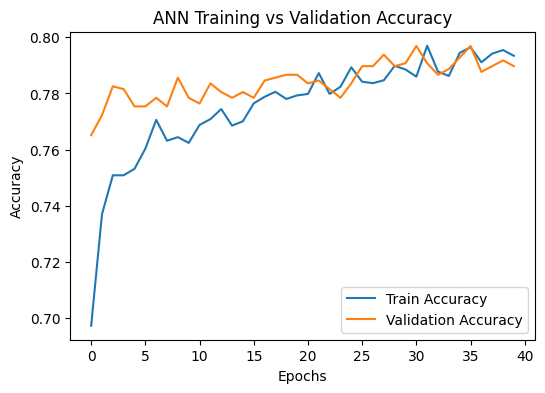

In [31]:
plt.figure(figsize=(6,4))

plt.plot(history_ann.history['accuracy'], label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')

plt.title("ANN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

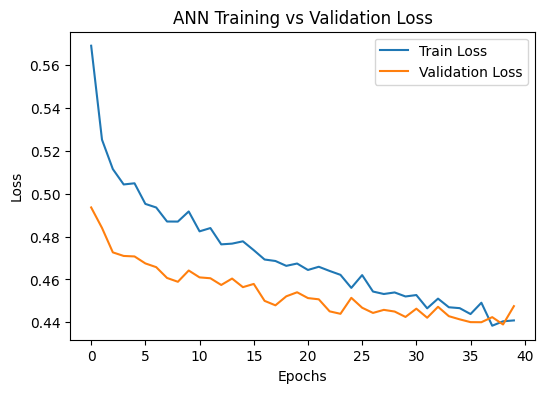

In [33]:
plt.figure(figsize=(6,4))

plt.plot(history_ann.history['loss'], label='Train Loss')
plt.plot(history_ann.history['val_loss'], label='Validation Loss')

plt.title("ANN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


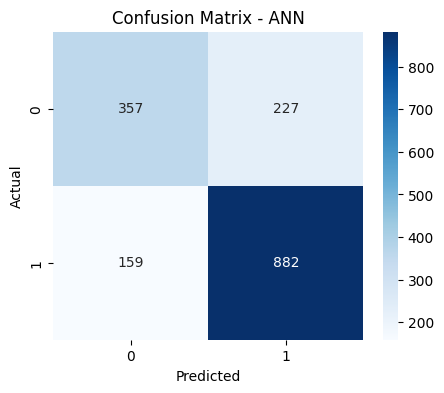

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Predictions
y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [27]:
cnn = Sequential()

cnn.add(Conv1D(64, kernel_size=2, activation='relu',
               input_shape=(X_train.shape[1], 1)))

cnn.add(Flatten())

cnn.add(Dense(64, activation='relu'))
cnn.add(Dropout(0.3))

cnn.add(Dense(1, activation='sigmoid'))

cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
history_cnn = cnn.fit(
    X_train_cnn, y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7365 - loss: 0.5343 - val_accuracy: 0.7692 - val_loss: 0.4727
Epoch 2/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7570 - loss: 0.5011 - val_accuracy: 0.7805 - val_loss: 0.4705
Epoch 3/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7578 - loss: 0.4957 - val_accuracy: 0.7856 - val_loss: 0.4592
Epoch 4/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7721 - loss: 0.4861 - val_accuracy: 0.7672 - val_loss: 0.4710
Epoch 5/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7673 - loss: 0.4849 - val_accuracy: 0.7826 - val_loss: 0.4559
Epoch 6/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7706 - loss: 0.4842 - val_accuracy: 0.7805 - val_loss: 0.4580
Epoch 7/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7642 - loss: 0.4784 - val_accuracy: 0.7815 - val_loss: 0.4527
Epoch 8/40
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7773 - loss: 0.4761 - val_accuracy: 0.

In [29]:
cnn_loss, cnn_acc = cnn.evaluate(X_test_cnn, y_test)

print("CNN Accuracy:", cnn_acc)

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7686 - loss: 0.4957
CNN Accuracy: 0.7686153650283813


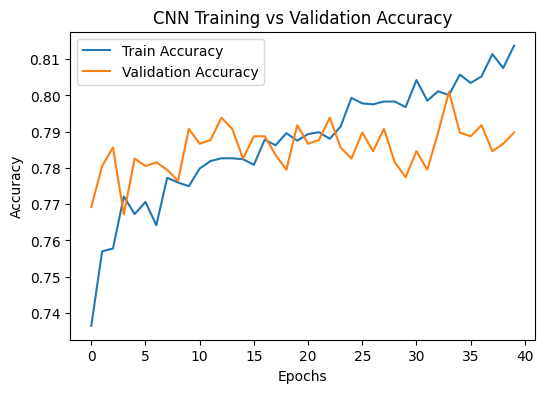

In [34]:
plt.figure(figsize=(6,4))

plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')

plt.title("CNN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

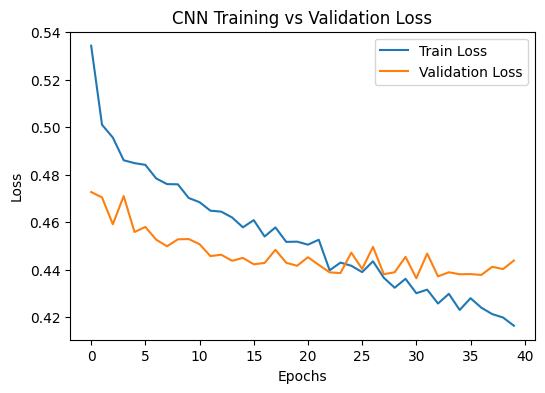

In [35]:
plt.figure(figsize=(6,4))

plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')

plt.title("CNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


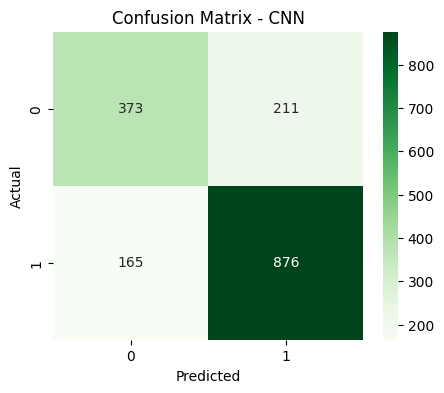

In [39]:
y_pred_cnn = (cnn.predict(X_test_cnn) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

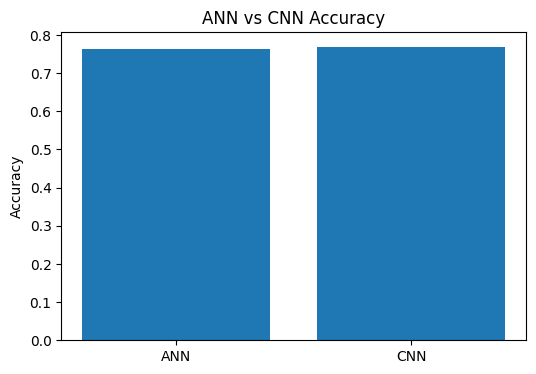

In [30]:
plt.figure(figsize=(6,4))

plt.bar(['ANN', 'CNN'], [ann_acc, cnn_acc])

plt.title("ANN vs CNN Accuracy")
plt.ylabel("Accuracy")

plt.show()